In [29]:
import numpy as np
# qa_file = "/mnt/bn/nlhei-nas/liubangya/proj/vlm/workspace/image_scannetpp_16x24_6/pairs/qa_pairs_qwen.train.json"
# max_H = 16
# max_W = 24

qa_file = "/mnt/bn/nlhei-nas/liubangya/proj/vlm/workspace/image_nuscenes_9x16_4/pairs/qa_pairs_qwen.train.json"
max_H = 9
max_W = 16
# ctr in shape of HxW
ctr = np.zeros((max_H, max_W), dtype=np.int32)

with open(qa_file, "r") as f:
    qas = json.load(f)

def parse(gt):
    coords = []
    frames = gt.split(", ")
    for f in frames:
        f, x, y = f.split(" ")
        f, x, y = int(f), int(x), int(y)
        coords.append((x, y))
    return coords

for qa in qas:
    gt = qa["conversations"][-1]["value"]
    coords = parse(gt)
    for co in coords:
        x, y = co
        ctr[x, y] += 1




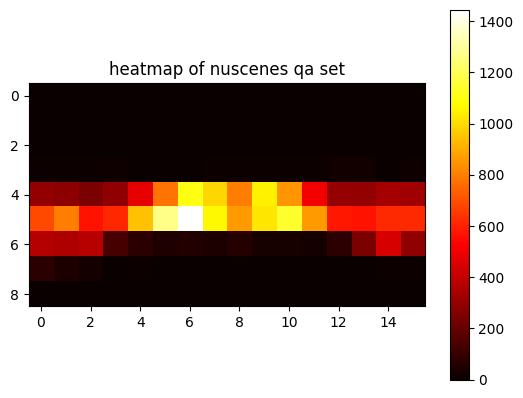

In [30]:
# drow the heat map of ctr
from matplotlib import pyplot as plt
plt.title("heatmap of nuscenes qa set")
plt.imshow(ctr, cmap='hot', interpolation='nearest')
plt.colorbar()
plt.show()

